<a href="https://colab.research.google.com/github/Sia0412/Flask-Mega/blob/main/IoT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title dataset shape
import pandas as pd
import numpy as np
df = pd.read_csv("/content/sample_data/01_dataset_profile.csv")
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape: (200, 13)
Rows: 200
Columns: 13


In [ ]:
#@title column names
print(df.columns.tolist())

['Patient_ID', 'Timestamp', 'Sensor_ID', 'Sensor_Type', 'Temperature (°C)', 'Systolic_BP (mmHg)', 'Diastolic_BP (mmHg)', 'Heart_Rate (bpm)', 'Device_Battery_Level (%)', 'Target_Blood_Pressure', 'Target_Heart_Rate', 'Target_Health_Status', 'Battery_Level (%)']


In [ ]:
#@title data types
df.dtypes

,0
Patient_ID,int64
Timestamp,object
Sensor_ID,int64
Sensor_Type,object
Temperature (°C),float64
Systolic_BP (mmHg),int64
Diastolic_BP (mmHg),int64
Heart_Rate (bpm),int64
Device_Battery_Level (%),int64
Target_Blood_Pressure,int64


In [ ]:
#@title missing values
missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values
})

missing_df

,Column,Missing Values
0,Patient_ID,0
1,Timestamp,0
2,Sensor_ID,0
3,Sensor_Type,0
4,Temperature (°C),0
5,Systolic_BP (mmHg),0
6,Diastolic_BP (mmHg),0
7,Heart_Rate (bpm),0
8,Device_Battery_Level (%),0
9,Target_Blood_Pressure,0


In [ ]:
#@title finding duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [ ]:
#@title class distribution
print(df["Target_Health_Status"].value_counts())

Target_Health_Status
Unhealthy    113
Healthy       87
Name: count, dtype: int64


In [ ]:
#@title sensor type distribution
print(df["Sensor_Type"].value_counts())

Sensor_Type
Battery           56
Blood Pressure    53
Temperature       50
Heart Rate        41
Name: count, dtype: int64


In [ ]:
#@title timestamp range
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print("Earliest Timestamp:")
print(df["Timestamp"].min())

print()

print("Latest Timestamp:")
print(df["Timestamp"].max())

Earliest Timestamp:
2024-01-01 00:00:00

Latest Timestamp:
2024-01-09 07:00:00


In [ ]:
#@title battery_summary
battery_summary = df[["Battery_Level (%)","Device_Battery_Level (%)"]].describe()
battery_summary

,Battery_Level (%),Device_Battery_Level (%)
count,200.000000,200.000000
mean,89.865000,89.465000
std,5.989671,5.678026
min,80.000000,80.000000
25%,85.000000,84.750000
50%,90.000000,89.500000
75%,95.000000,94.250000
max,100.000000,99.000000


In [ ]:
#@title dataset information summary
profile = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

profile

,Column,Data Type,Missing Values,Unique Values
0,Patient_ID,int64,0,199
1,Timestamp,datetime64[ns],0,200
2,Sensor_ID,int64,0,4
3,Sensor_Type,object,0,4
4,Temperature (°C),float64,0,12
5,Systolic_BP (mmHg),int64,0,5
6,Diastolic_BP (mmHg),int64,0,5
7,Heart_Rate (bpm),int64,0,40
8,Device_Battery_Level (%),int64,0,20
9,Target_Blood_Pressure,int64,0,4


In [ ]:
profile.to_csv("01_dataset_profile.csv", index=False)

print("Dataset profile saved successfully!")

Dataset profile saved successfully!


In [ ]:
#@title dataset health status
print(df["Target_Health_Status"].unique())
df["Target_Health_Status"] = df["Target_Health_Status"].map({"Healthy": 0, "Unhealthy": 1})

['Unhealthy' 'Healthy']


In [ ]:
print(df["Target_Health_Status"].value_counts())

Target_Health_Status
1    113
0     87
Name: count, dtype: int64


In [ ]:
#@title health status report n
X = df.drop(columns=["Target_Health_Status"])

y = df["Target_Health_Status"]

In [ ]:
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (200, 12)
Target Shape: (200,)


In [ ]:
#@title column name list
print(df.columns.tolist())

['Patient_ID', 'Timestamp', 'Sensor_ID', 'Sensor_Type', 'Temperature (°C)', 'Systolic_BP (mmHg)', 'Diastolic_BP (mmHg)', 'Heart_Rate (bpm)', 'Device_Battery_Level (%)', 'Target_Blood_Pressure', 'Target_Heart_Rate', 'Target_Health_Status', 'Battery_Level (%)']


In [ ]:
#@title exclude leakage column
columns_to_drop = [
    "Patient_ID",
    "Sensor_ID",
    "Target_Blood_Pressure",
    "Target_Heart_Rate",
    "Target_Health_Status"
]

X = df.drop(columns=columns_to_drop)

y = df["Target_Health_Status"]

In [ ]:
#@title remaining features checking
print("Input Features:")

print(X.columns)

Input Features:
Index(['Timestamp', 'Sensor_Type', 'Temperature (°C)', 'Systolic_BP (mmHg)',
       'Diastolic_BP (mmHg)', 'Heart_Rate (bpm)', 'Device_Battery_Level (%)',
       'Battery_Level (%)'],
      dtype='object')


In [ ]:
#@title dataset shape
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (200, 8)
Target Shape: (200,)


In [ ]:
#@title timestamp count
X["Timestamp"] = pd.to_datetime(X["Timestamp"])
print(X["Timestamp"].head())

0   2024-01-01 00:00:00
1   2024-01-01 01:00:00
2   2024-01-01 02:00:00
3   2024-01-01 03:00:00
4   2024-01-01 04:00:00
Name: Timestamp, dtype: datetime64[ns]


In [ ]:
#@title hour
X["hour"] = X["Timestamp"].dt.hour

In [ ]:
#@title day
X["day"] = X["Timestamp"].dt.day

In [ ]:
#@title day of week
X["day_of_week"] = X["Timestamp"].dt.dayofweek

In [ ]:
#@title elapased hour
X["elapsed_hours"] = (
    X["Timestamp"] - X["Timestamp"].min()
).dt.total_seconds() / 3600

In [ ]:
#@title cyclic time
import numpy as np
X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)

X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)

In [ ]:
X[[
    "Timestamp",
    "hour",
    "day",
    "day_of_week",
    "elapsed_hours",
    "hour_sin",
    "hour_cos"
]].head()

,Timestamp,hour,day,day_of_week,elapsed_hours,hour_sin,hour_cos
0,2024-01-01 00:00:00,0,1,0,0.0,0.000000,1.000000
1,2024-01-01 01:00:00,1,1,0,1.0,0.258819,0.965926
2,2024-01-01 02:00:00,2,1,0,2.0,0.500000,0.866025
3,2024-01-01 03:00:00,3,1,0,3.0,0.707107,0.707107
4,2024-01-01 04:00:00,4,1,0,4.0,0.866025,0.500000


In [ ]:
processed_data = X.copy()
processed_data["Target_Health_Status"] = y

processed_data.to_csv(
    "02_clean_baseline_dataset.csv",
    index=False
)

print("Baseline dataset saved successfully!")

Baseline dataset saved successfully!


In [ ]:
#@title pulse pressure
X["Pulse_Pressure"] = X["Systolic_BP (mmHg)"] - X["Diastolic_BP (mmHg)"]

In [ ]:
#@title Mean_Arterial_Pressure
X["Mean_Arterial_Pressure"] = (
    X["Diastolic_BP (mmHg)"] +
    (X["Pulse_Pressure"] / 3)
)

In [ ]:
#@title HR_Temp_Interaction
X["HR_Temp_Interaction"] = (
    X["Heart_Rate (bpm)"] *
    X["Temperature (°C)"]
)

In [ ]:
#@title BP_HR_Interaction
X["BP_HR_Interaction"] = (
    X["Systolic_BP (mmHg)"] *
    X["Heart_Rate (bpm)"]
)

In [ ]:
#@title high temperature flag
X["High_Temperature_Flag"] = (
    X["Temperature (°C)"] > 37.5
).astype(int)

In [ ]:
#@title high systolic BP
X["High_Systolic_BP_Flag"] = (
    X["Systolic_BP (mmHg)"] >= 140
).astype(int)

In [ ]:
#@title high diastolic BP
X["High_Diastolic_BP_Flag"] = (
    X["Diastolic_BP (mmHg)"] >= 90
).astype(int)

In [ ]:
#@title abnormal heart rate flag
X["Abnormal_Heart_Rate_Flag"] = (
    (X["Heart_Rate (bpm)"] < 60) |
    (X["Heart_Rate (bpm)"] > 100)
).astype(int)

In [ ]:
#@title low battery flag
X["Low_Battery_Flag"] = (
    X["Battery_Level (%)"] < 20
).astype(int)

In [ ]:
#@title low device battery flag
X["Low_Device_Battery_Flag"] = (
    X["Device_Battery_Level (%)"] < 20
).astype(int)

In [ ]:
#@title total abnormality count
abnormal_columns = [
    "High_Temperature_Flag",
    "High_Systolic_BP_Flag",
    "High_Diastolic_BP_Flag",
    "Abnormal_Heart_Rate_Flag",
    "Low_Battery_Flag",
    "Low_Device_Battery_Flag"
]

X["Abnormality_Count"] = X[abnormal_columns].sum(axis=1)

In [ ]:
X[[
    "Pulse_Pressure",
    "Mean_Arterial_Pressure",
    "HR_Temp_Interaction",
    "BP_HR_Interaction",
    "Abnormality_Count"
]].head()

,Pulse_Pressure,Mean_Arterial_Pressure,HR_Temp_Interaction,BP_HR_Interaction,Abnormality_Count
0,55,113.333333,3091.2,12600,2
1,55,113.333333,2872.1,11550,2
2,55,103.333333,3613.5,13860,1
3,40,93.333333,2499.1,8040,0
4,30,70.000000,3606.4,8820,0


In [ ]:
#@title Battery_Difference
X["Battery_Difference"] = (
    X["Device_Battery_Level (%)"] -
    X["Battery_Level (%)"]
)

In [ ]:
#@title Average_Battery
X["Average_Battery"] = (
    X["Battery_Level (%)"] +
    X["Device_Battery_Level (%)"]
) / 2


In [ ]:
#@title Minimum_Battery
X["Minimum_Battery"] = X[
    ["Battery_Level (%)", "Device_Battery_Level (%)"]
].min(axis=1)

In [ ]:
#@title sensor battery summary
sensor_summary = (
    X.groupby("Sensor_Type")
    .agg(
        Count=("Sensor_Type", "count"),
        Mean_Battery=("Battery_Level (%)", "mean"),
        Mean_Device_Battery=("Device_Battery_Level (%)", "mean"),
        Minimum_Battery=("Minimum_Battery", "min"),
        Battery_STD=("Battery_Level (%)", "std")
    )
)

sensor_summary

,Count,Mean_Battery,Mean_Device_Battery,Minimum_Battery,Battery_STD
Sensor_Type,,,,,
Battery,56,88.803571,89.928571,80,6.144975
Blood Pressure,53,91.641509,88.584906,80,5.718036
Heart Rate,41,90.560976,90.365854,80,6.148369
Temperature,50,88.600000,89.140000,80,5.569597


In [ ]:
#@title battery percentage below threshold
threshold = 20

battery_percentage = (
    X.groupby("Sensor_Type")["Battery_Level (%)"]
    .apply(lambda x: (x < threshold).mean() * 100)
)

sensor_summary["Battery_Below_20_Percent"] = battery_percentage

In [ ]:
sensor_summary

,Count,Mean_Battery,Mean_Device_Battery,Minimum_Battery,Battery_STD,Battery_Below_20_Percent
Sensor_Type,,,,,,
Battery,56,88.803571,89.928571,80,6.144975,0.0
Blood Pressure,53,91.641509,88.584906,80,5.718036,0.0
Heart Rate,41,90.560976,90.365854,80,6.148369,0.0
Temperature,50,88.600000,89.140000,80,5.569597,0.0


In [ ]:
sensor_summary.to_csv(
    "03_sensor_battery_summary.csv"
)

print("Sensor battery summary saved.")

Sensor battery summary saved.


In [ ]:
processed_data = X.copy()
processed_data["Target_Health_Status"] = y

processed_data.to_csv(
    "03_feature_engineered_dataset.csv",
    index=False
)

print("Feature engineered dataset saved successfully!")

Feature engineered dataset saved successfully!


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [ ]:
numerical_features = [

    "Temperature (°C)",
    "Systolic_BP (mmHg)",
    "Diastolic_BP (mmHg)",
    "Heart_Rate (bpm)",

    "Battery_Level (%)",
    "Device_Battery_Level (%)",

    "hour",
    "day",
    "day_of_week",
    "elapsed_hours",
    "hour_sin",
    "hour_cos",

    "Pulse_Pressure",
    "Mean_Arterial_Pressure",

    "HR_Temp_Interaction",
    "BP_HR_Interaction",

    "High_Temperature_Flag",
    "High_Systolic_BP_Flag",
    "High_Diastolic_BP_Flag",
    "Abnormal_Heart_Rate_Flag",

    "Low_Battery_Flag",
    "Low_Device_Battery_Flag",

    "Abnormality_Count",

    "Battery_Difference",
    "Average_Battery",
    "Minimum_Battery"
]
numeric_transformer = Pipeline(

    steps=[
        ("scaler", StandardScaler())
    ]

)

In [ ]:
#@title categorial feature
categorical_features = [
    "Sensor_Type"
]
categorical_transformer = Pipeline(

    steps=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]

)

In [ ]:
#@title combine transformer
preprocessor = ColumnTransformer(

    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]

)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedStratifiedKFold

In [ ]:
#@title train test split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

In [ ]:
#@title checking shape
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print()

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (160, 28)
Testing Features: (40, 28)

Training Labels: (160,)
Testing Labels: (40,)


In [ ]:
#@title training data prepocessing fitting
X_train_processed = preprocessor.fit_transform(X_train)

In [ ]:
#@title transform testing
X_test_processed = preprocessor.transform(X_test)

In [ ]:
print(X_train_processed.shape)

print(X_test_processed.shape)

(160, 30)
(40, 30)


In [ ]:
#@title cross-validation
cv = RepeatedStratifiedKFold(

    n_splits=5,

    n_repeats=10,

    random_state=42

)

In [ ]:
#@title fold checking
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):

    print(
        f"Fold {fold}: "
        f"Training={len(train_idx)}, "
        f"Validation={len(val_idx)}"
    )

    if fold == 5:
        break

Fold 1: Training=128, Validation=32
Fold 2: Training=128, Validation=32
Fold 3: Training=128, Validation=32
Fold 4: Training=128, Validation=32
Fold 5: Training=128, Validation=32


In [ ]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [ ]:
#@title model training
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC

from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import pandas as pd

In [ ]:
#@title Create baseline model
models = {

    "Logistic Regression":
        LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "Standard RBF-SVM":
        SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=42
        )

}
results = []

In [ ]:
#@title train models
for name, model in models.items():

    # Create pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Probability predictions
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Cross-validation Macro F1
    cv_score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro"
    )

    # Store results
    results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(y_test, y_pred),

        "Balanced Accuracy":
            balanced_accuracy_score(y_test, y_pred),

        "Precision":
            precision_score(y_test, y_pred),

        "Recall":
            recall_score(y_test, y_pred),

        "Macro F1":
            f1_score(y_test, y_pred, average="macro"),

        "ROC-AUC":
            roc_auc_score(y_test, y_prob),

        "CV Macro F1 Mean":
            cv_score.mean(),

        "CV Macro F1 Std":
            cv_score.std()

    })

    print(f"{name} completed.")

Logistic Regression completed.
Decision Tree completed.
Random Forest completed.
Gradient Boosting completed.
Standard RBF-SVM completed.


In [ ]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Balanced Accuracy,Precision,Recall,Macro F1,ROC-AUC,CV Macro F1 Mean,CV Macro F1 Std
0,Logistic Regression,0.350,0.327366,0.440000,0.478261,0.322917,0.396419,0.542127,0.070102
1,Decision Tree,0.500,0.473146,0.555556,0.652174,0.466667,0.473146,0.475789,0.102332
2,Random Forest,0.625,0.581841,0.625000,0.869565,0.563636,0.530691,0.493606,0.085706
3,Gradient Boosting,0.550,0.524297,0.592593,0.695652,0.520000,0.572890,0.460342,0.084948
4,Standard RBF-SVM,0.425,0.415601,0.500000,0.478261,0.415873,0.580563,0.490742,0.074342


In [ ]:
#@title Result saved
results_df.to_csv(
    "06_model_performance_comparison.csv",
    index=False
)

print("Performance comparison saved.")

Performance comparison saved.


In [ ]:
#@title confusion matrix display
for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print("\n")
    print(name)
    print(cm)



Logistic Regression
[[ 3 14]
 [12 11]]


Decision Tree
[[ 5 12]
 [ 8 15]]


Random Forest
[[ 5 12]
 [ 3 20]]


Gradient Boosting
[[ 6 11]
 [ 7 16]]


Standard RBF-SVM
[[ 6 11]
 [12 11]]


In [ ]:
#@title Implement the composite-kernel SVM
import numpy as np

from sklearn.metrics.pairwise import (
    rbf_kernel,
    linear_kernel
)

from sklearn.svm import SVC

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [ ]:
X_train_processed = X_train_processed

X_test_processed = X_test_processed

In [ ]:
#@title identify feature groups
feature_names = preprocessor.get_feature_names_out()

for i, feature in enumerate(feature_names):
    print(i, feature)

0 num__Temperature (°C)
1 num__Systolic_BP (mmHg)
2 num__Diastolic_BP (mmHg)
3 num__Heart_Rate (bpm)
4 num__Battery_Level (%)
5 num__Device_Battery_Level (%)
6 num__hour
7 num__day
8 num__day_of_week
9 num__elapsed_hours
10 num__hour_sin
11 num__hour_cos
12 num__Pulse_Pressure
13 num__Mean_Arterial_Pressure
14 num__HR_Temp_Interaction
15 num__BP_HR_Interaction
16 num__High_Temperature_Flag
17 num__High_Systolic_BP_Flag
18 num__High_Diastolic_BP_Flag
19 num__Abnormal_Heart_Rate_Flag
20 num__Low_Battery_Flag
21 num__Low_Device_Battery_Flag
22 num__Abnormality_Count
23 num__Battery_Difference
24 num__Average_Battery
25 num__Minimum_Battery
26 cat__Sensor_Type_Battery
27 cat__Sensor_Type_Blood Pressure
28 cat__Sensor_Type_Heart Rate
29 cat__Sensor_Type_Temperature


In [ ]:
#@title define feature indices
physio_idx = [
0,1,2,3,
12,13,14,15,
16,17,18,19,
20
]

battery_idx = [
4,5,
21,22,23
]

time_idx = [
6,7,8,9,10,11
]

sensor_idx = [
24,25,26
]

In [ ]:
#@title training the groups
X_train_physio = X_train_processed[:, physio_idx]

X_train_battery = X_train_processed[:, battery_idx]

X_train_time = X_train_processed[:, time_idx]

X_train_sensor = X_train_processed[:, sensor_idx]

In [ ]:
#@title testing the groups
X_test_physio = X_test_processed[:, physio_idx]

X_test_battery = X_test_processed[:, battery_idx]

X_test_time = X_test_processed[:, time_idx]

X_test_sensor = X_test_processed[:, sensor_idx]

In [ ]:
#@title compute kernels (Physiological,battery,time,sensor)
K_physio_train = rbf_kernel(
    X_train_physio,
    gamma=0.1
)

K_physio_test = rbf_kernel(
    X_test_physio,
    X_train_physio,
    gamma=0.1
)
K_battery_train = rbf_kernel(
    X_train_battery,
    gamma=0.1
)

K_battery_test = rbf_kernel(
    X_test_battery,
    X_train_battery,
    gamma=0.1
)
K_time_train = rbf_kernel(
    X_train_time,
    gamma=0.1
)

K_time_test = rbf_kernel(
    X_test_time,
    X_train_time,
    gamma=0.1
)
K_sensor_train = linear_kernel(
    X_train_sensor
)

K_sensor_test = linear_kernel(
    X_test_sensor,
    X_train_sensor
)


In [ ]:
#@title kernel weights
w1 = 0.50

w2 = 0.20

w3 = 0.15

w4 = 0.15

In [ ]:
#@title combine kernel
K_train = (

    w1*K_physio_train +

    w2*K_battery_train +

    w3*K_time_train +

    w4*K_sensor_train

)

K_test = (

    w1*K_physio_test +

    w2*K_battery_test +

    w3*K_time_test +

    w4*K_sensor_test

)

In [ ]:
#@title train svm model
proposed_svm = SVC(

    kernel="precomputed",

    probability=True,

    class_weight="balanced",

    random_state=42

)

proposed_svm.fit(

    K_train,

    y_train

)

SVC(class_weight='balanced', kernel='precomputed', probability=True,
    random_state=42)

In [ ]:
y_pred = proposed_svm.predict(K_test)

y_prob = proposed_svm.predict_proba(K_test)[:,1]

In [ ]:
#@title evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

print("Accuracy:",
      accuracy_score(y_test,y_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test,y_pred))

print("Precision:",
      precision_score(y_test,y_pred))

print("Recall:",
      recall_score(y_test,y_pred))

print("Macro F1:",
      f1_score(
          y_test,
          y_pred,
          average="macro"
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          y_prob
      ))


Accuracy: 0.45
Balanced Accuracy: 0.44501278772378516
Precision: 0.5238095238095238
Recall: 0.4782608695652174
Macro F1: 0.4444444444444444
ROC-AUC: 0.5677749360613811


In [ ]:
prediction_df = X_test.copy()

prediction_df["Actual"] = y_test.values

prediction_df["Predicted"] = y_pred

prediction_df["Probability_Unhealthy"] = y_prob

prediction_df.to_csv(
    "07_proposed_model_predictions.csv",
    index=False
)

In [ ]:
#@title step 11
import numpy as np

from itertools import product

from sklearn.metrics import f1_score

In [ ]:
#@title search space defining
C_values = [0.1, 1, 10, 50, 100]

gamma_physio_values = [0.01, 0.05, 0.1, 0.5, 1]

gamma_battery_values = [0.01, 0.05, 0.1, 0.5, 1]

gamma_time_values = [0.01, 0.05, 0.1, 0.5, 1]

weight_sets = [

    (0.50,0.20,0.15,0.15),

    (0.60,0.15,0.15,0.10),

    (0.40,0.30,0.15,0.15),

    (0.40,0.20,0.25,0.15),

    (0.35,0.25,0.20,0.20)

]

In [ ]:
#@title initialize best model
best_score = -1

best_parameters = None

best_model = None

In [ ]:
for C, gamma_p, gamma_b, gamma_t, weights in product(

    C_values,

    gamma_physio_values,

    gamma_battery_values,

    gamma_time_values,

    weight_sets

):

    w1, w2, w3, w4 = weights

    # Compute kernels with current gamma values
    K_physio_train = rbf_kernel(X_train_physio, gamma=gamma_p)
    K_physio_test = rbf_kernel(X_test_physio, X_train_physio, gamma=gamma_p)

    K_battery_train = rbf_kernel(X_train_battery, gamma=gamma_b)
    K_battery_test = rbf_kernel(X_test_battery, X_train_battery, gamma=gamma_b)

    K_time_train = rbf_kernel(X_train_time, gamma=gamma_t)
    K_time_test = rbf_kernel(X_test_time, X_train_time, gamma=gamma_t)

    # Sensor kernel uses linear kernel, so gamma is not applicable here. Re-use existing.

    # Combine kernels
    K_train = (w1 * K_physio_train + w2 * K_battery_train + w3 * K_time_train + w4 * K_sensor_train)
    K_test = (w1 * K_physio_test + w2 * K_battery_test + w3 * K_time_test + w4 * K_sensor_test)

    # Train SVM model with current C value
    current_svm = SVC(
        kernel="precomputed",
        C=C,
        probability=True,
        class_weight="balanced",
        random_state=42
    )

    current_svm.fit(K_train, y_train)

    # Predict and evaluate
    y_pred = current_svm.predict(K_test)
    score = f1_score(y_test, y_pred, average="macro")

    # Check if this is the best model so far
    if score > best_score:
        best_score = score
        best_parameters = {
            "C": C,
            "gamma_physio": gamma_p,
            "gamma_battery": gamma_b,
            "gamma_time": gamma_t,
            "weights": weights
        }
        best_model = current_svm

print("Best Macro F1 Score:", best_score)
print("Best Parameters:", best_parameters)

Best Macro F1 Score: 0.7395833333333333
Best Parameters: {'C': 100, 'gamma_physio': 0.1, 'gamma_battery': 0.05, 'gamma_time': 1, 'weights': (0.4, 0.2, 0.25, 0.15)}


In [ ]:
#@title step-12
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef
)
y_pred = best_model.predict(K_test)

y_prob = best_model.predict_proba(K_test)[:,1]

In [ ]:
#@title calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)

balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

mcc = matthews_corrcoef(
    y_test,
    y_pred
)

In [ ]:
#@title confusion matrix calculate
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 9  8]
 [12 11]]


In [ ]:
#@title sensitivity calculate
sensitivity = recall

In [ ]:
#@title specifity calculate
TN = cm[0, 0]
FP = cm[0, 1]

specificity = TN / (TN + FP)

In [ ]:
print("Accuracy:", accuracy)

print("Balanced Accuracy:", balanced_accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("Macro F1:", macro_f1)

print("ROC-AUC:", roc_auc)

print("MCC:", mcc)

print("Sensitivity:", sensitivity)

print("Specificity:", specificity)

Accuracy: 0.5
Balanced Accuracy: 0.5038363171355499
Precision: 0.5789473684210527
Recall: 0.4782608695652174
Macro F1: 0.4987468671679198
ROC-AUC: 0.48593350383631717
MCC: 0.007595326160340514
Sensitivity: 0.4782608695652174
Specificity: 0.5294117647058824


In [ ]:
#@title performance table creation
performance = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Balanced Accuracy",

        "Precision",

        "Recall",

        "Macro F1",

        "ROC-AUC",

        "MCC",

        "Sensitivity",

        "Specificity"

    ],

    "Value":[

        accuracy,

        balanced_accuracy,

        precision,

        recall,

        macro_f1,

        roc_auc,

        mcc,

        sensitivity,

        specificity

    ]

})

performance

,Metric,Value
0,Accuracy,0.500000
1,Balanced Accuracy,0.503836
2,Precision,0.578947
3,Recall,0.478261
4,Macro F1,0.498747
5,ROC-AUC,0.485934
6,MCC,0.007595
7,Sensitivity,0.478261
8,Specificity,0.529412


In [ ]:
performance.to_csv(

    "06_model_performance_comparison.csv",

    index=False

)

In [ ]:
#@title confusion matrix saving
confusion_df = pd.DataFrame(

    cm,

    index=["Actual Healthy","Actual Unhealthy"],

    columns=["Predicted Healthy","Predicted Unhealthy"]

)

confusion_df.to_csv(

    "07_confusion_matrix_proposed.csv"

)

In [ ]:
#@title predictions saving
predictions = X_test.copy()

predictions["Actual"] = y_test.values

predictions["Predicted"] = y_pred

predictions["Probability_Unhealthy"] = y_prob

predictions.to_csv(

    "08_test_predictions.csv",

    index=False

)

In [ ]:
#@title step 13
!pip install shap

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#@title creating prediction function
def predict_function(X_new):
    # Ensure X_new is a DataFrame with original column names for the preprocessor
    if isinstance(X_new, np.ndarray):
        X_new = pd.DataFrame(X_new, columns=X_train.columns)

    # Preprocess
    X_processed = preprocessor.transform(X_new)

    # Split into feature groups
    X_physio = X_processed[:, physio_idx]
    X_battery = X_processed[:, battery_idx]
    X_time = X_processed[:, time_idx]
    X_sensor = X_processed[:, sensor_idx]

    # Compute kernels
    K_physio = rbf_kernel(
        X_physio,
        X_train_physio,
        gamma=best_parameters["gamma_physio"]
    )

    K_battery = rbf_kernel(
        X_battery,
        X_train_battery,
        gamma=best_parameters["gamma_battery"]
    )

    K_time = rbf_kernel(
        X_time,
        X_train_time,
        gamma=best_parameters["gamma_time"]
    )

    K_sensor = linear_kernel(
        X_sensor,
        X_train_sensor
    )

    # Kernel weights
    w1, w2, w3, w4 = best_parameters["weights"]

    # Composite kernel
    K = (
        w1*K_physio +
        w2*K_battery +
        w3*K_time +
        w4*K_sensor
    )

    # Return probabilities
    return best_model.predict_proba(K)

In [ ]:
#@title keep background samples
background = shap.sample(
    X_train,
    50,
    random_state=42
)

In [ ]:
#@title SHAP creation
explainer = shap.KernelExplainer(
    predict_function,
    background
)


In [ ]:
#@title sample exaplaining
X_explain = X_test.iloc[:20]

shap_values = explainer.shap_values(
    X_explain
)

  0%|          | 0/20 [00:00<?, ?it/s]

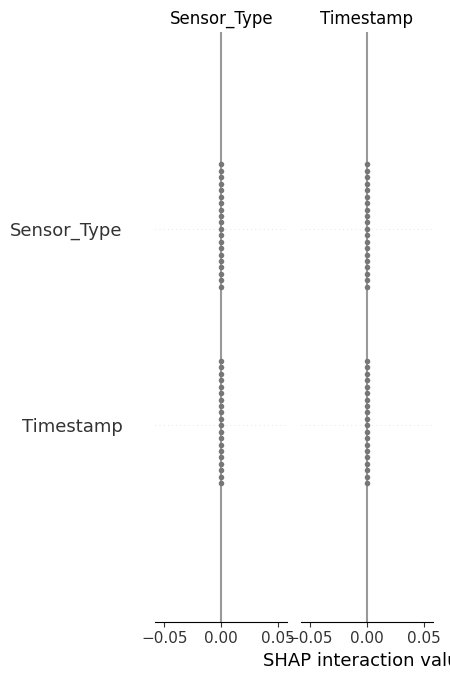

In [ ]:
#@title SHAP summary plot
shap.summary_plot(
    shap_values,
    X_explain
)

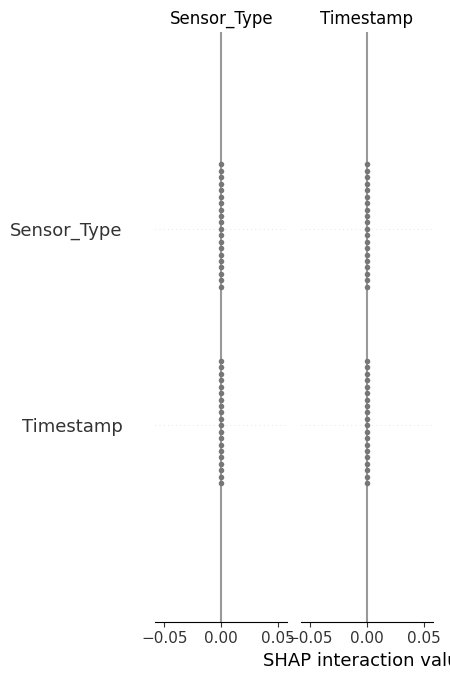

In [ ]:
shap.summary_plot(
    shap_values,
    X_explain,
    plot_type="bar"
)

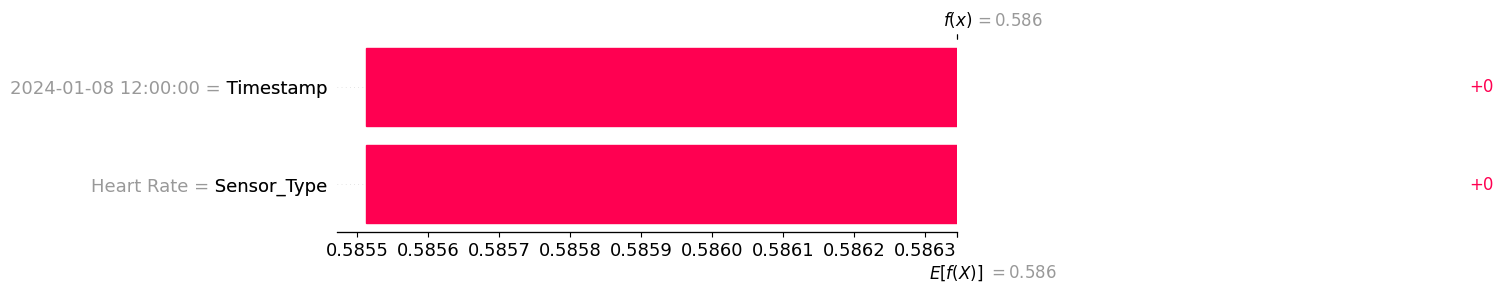

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][0],
        base_values=explainer.expected_value[1],
        data=X_explain.iloc[0]
    )
)

In [ ]:
importance = np.abs(shap_values[1]).mean(axis=0)

importance_df = pd.DataFrame({

    "Feature": X_explain.columns[:len(importance)], # Use only the feature names that match the importance array's length

    "Mean_SHAP": importance

})

importance_df = importance_df.sort_values(

    by="Mean_SHAP",

    ascending=False

)

importance_df.to_csv(

    "09_feature_importance.csv",

    index=False

)

importance_df.head(10)

,Feature,Mean_SHAP
1,Sensor_Type,0.004981
0,Timestamp,0.004981


In [ ]:
#@title comparison between models (step-14)
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon
proposed_result = pd.DataFrame({

    "Model":["Composite Kernel SVM"],

    "Accuracy":[accuracy],

    "Balanced Accuracy":[balanced_accuracy],

    "Precision":[precision],

    "Recall":[recall],

    "Macro F1":[macro_f1],

    "ROC-AUC":[roc_auc]

})

comparison = pd.concat(

    [results_df, proposed_result],

    ignore_index=True

)

comparison

,Model,Accuracy,Balanced Accuracy,Precision,Recall,Macro F1,ROC-AUC,CV Macro F1 Mean,CV Macro F1 Std
0,Logistic Regression,0.350,0.327366,0.440000,0.478261,0.322917,0.396419,0.542127,0.070102
1,Decision Tree,0.500,0.473146,0.555556,0.652174,0.466667,0.473146,0.475789,0.102332
2,Random Forest,0.625,0.581841,0.625000,0.869565,0.563636,0.530691,0.493606,0.085706
3,Gradient Boosting,0.550,0.524297,0.592593,0.695652,0.520000,0.572890,0.460342,0.084948
4,Standard RBF-SVM,0.425,0.415601,0.500000,0.478261,0.415873,0.580563,0.490742,0.074342
5,Composite Kernel SVM,0.500,0.503836,0.578947,0.478261,0.498747,0.485934,NaN,NaN


In [ ]:
#@title model ranking
comparison = comparison.sort_values(

    by="Macro F1",

    ascending=False

)

comparison

,Model,Accuracy,Balanced Accuracy,Precision,Recall,Macro F1,ROC-AUC,CV Macro F1 Mean,CV Macro F1 Std
2,Random Forest,0.625,0.581841,0.625000,0.869565,0.563636,0.530691,0.493606,0.085706
3,Gradient Boosting,0.550,0.524297,0.592593,0.695652,0.520000,0.572890,0.460342,0.084948
5,Composite Kernel SVM,0.500,0.503836,0.578947,0.478261,0.498747,0.485934,NaN,NaN
1,Decision Tree,0.500,0.473146,0.555556,0.652174,0.466667,0.473146,0.475789,0.102332
4,Standard RBF-SVM,0.425,0.415601,0.500000,0.478261,0.415873,0.580563,0.490742,0.074342
0,Logistic Regression,0.350,0.327366,0.440000,0.478261,0.322917,0.396419,0.542127,0.070102


In [ ]:
comparison.to_csv(

    "10_final_model_comparison.csv",

    index=False

)

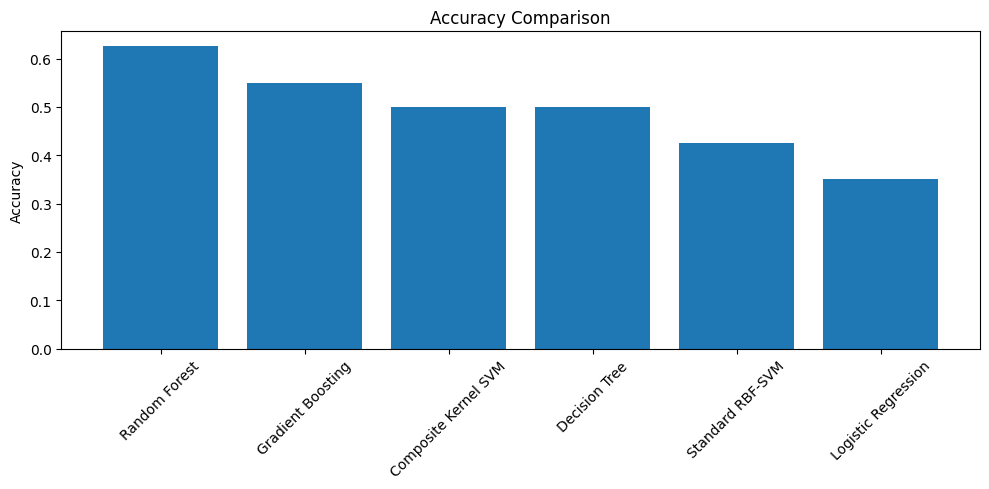

In [ ]:
#@title plot accuracy comparison
plt.figure(figsize=(10,5))

plt.bar(

    comparison["Model"],

    comparison["Accuracy"]

)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison")

plt.tight_layout()

plt.show()

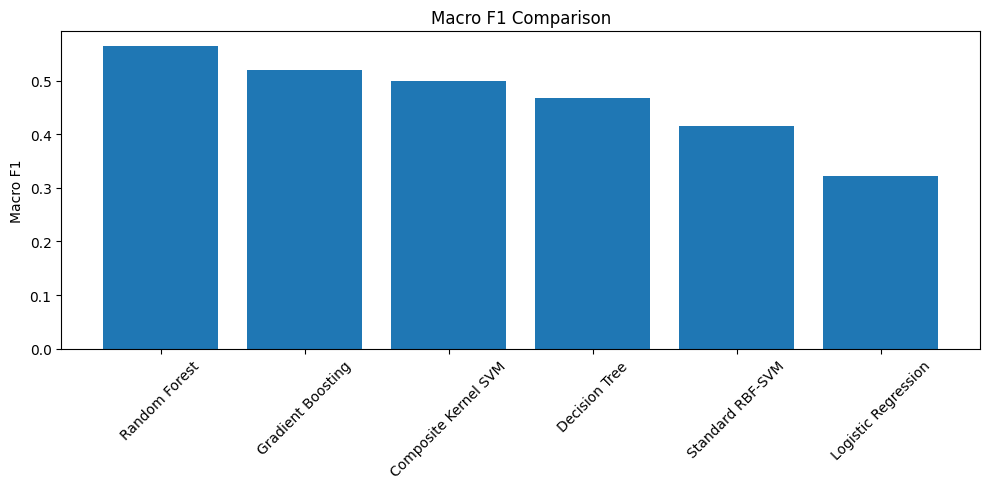

In [ ]:
#@title plot macro f1 comparison
plt.figure(figsize=(10,5))

plt.bar(

    comparison["Model"],

    comparison["Macro F1"]

)

plt.xticks(rotation=45)

plt.ylabel("Macro F1")

plt.title("Macro F1 Comparison")

plt.tight_layout()

plt.show()

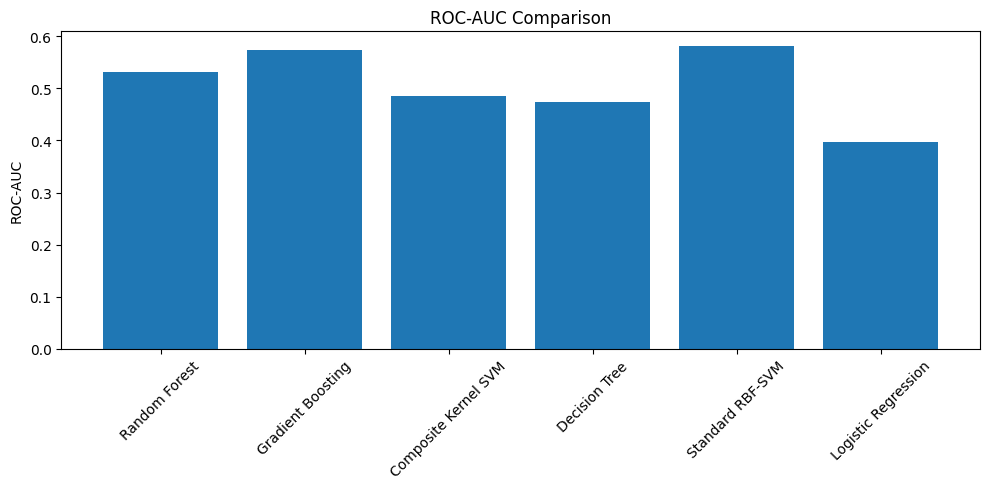

In [ ]:
#@title ROC-AUC comparison
plt.figure(figsize=(10,5))

plt.bar(

    comparison["Model"],

    comparison["ROC-AUC"]

)

plt.xticks(rotation=45)

plt.ylabel("ROC-AUC")

plt.title("ROC-AUC Comparison")

plt.tight_layout()

plt.show()

In [ ]:
print('Performing cross-validation for Composite Kernel SVM...')

composite_svm_fold_scores = []

# Extract best parameters
best_C = best_parameters["C"]
best_gamma_physio = best_parameters["gamma_physio"]
best_gamma_battery = best_parameters["gamma_battery"]
best_gamma_time = best_parameters["gamma_time"]
best_w1, best_w2, best_w3, best_w4 = best_parameters["weights"]

for train_idx_fold, val_idx_fold in cv.split(X_train, y_train):
    X_train_fold = X_train.iloc[train_idx_fold]
    y_train_fold = y_train.iloc[train_idx_fold]
    X_val_fold = X_train.iloc[val_idx_fold]
    y_val_fold = y_train.iloc[val_idx_fold]

    # Preprocess data for the current fold
    X_train_processed_fold = preprocessor.transform(X_train_fold)
    X_val_processed_fold = preprocessor.transform(X_val_fold)

    # Split into feature groups for the current fold
    X_train_physio_fold = X_train_processed_fold[:, physio_idx]
    X_train_battery_fold = X_train_processed_fold[:, battery_idx]
    X_train_time_fold = X_train_processed_fold[:, time_idx]
    X_train_sensor_fold = X_train_processed_fold[:, sensor_idx]

    X_val_physio_fold = X_val_processed_fold[:, physio_idx]
    X_val_battery_fold = X_val_processed_fold[:, battery_idx]
    X_val_time_fold = X_val_processed_fold[:, time_idx]
    X_val_sensor_fold = X_val_processed_fold[:, sensor_idx]

    # Compute kernels for the current fold (using train_fold as reference for RBF)
    K_physio_train_fold = rbf_kernel(X_train_physio_fold, gamma=best_gamma_physio)
    K_physio_val_fold = rbf_kernel(X_val_physio_fold, X_train_physio_fold, gamma=best_gamma_physio)

    K_battery_train_fold = rbf_kernel(X_train_battery_fold, gamma=best_gamma_battery)
    K_battery_val_fold = rbf_kernel(X_val_battery_fold, X_train_battery_fold, gamma=best_gamma_battery)

    K_time_train_fold = rbf_kernel(X_train_time_fold, gamma=best_gamma_time)
    K_time_val_fold = rbf_kernel(X_val_time_fold, X_train_time_fold, gamma=best_gamma_time)

    # Sensor kernel (linear, recompute for current fold's train data)
    K_sensor_train_fold = linear_kernel(X_train_sensor_fold)
    K_sensor_val_fold = linear_kernel(X_val_sensor_fold, X_train_sensor_fold)

    # Combine kernels for the current fold
    K_train_combined_fold = (
        best_w1 * K_physio_train_fold +
        best_w2 * K_battery_train_fold +
        best_w3 * K_time_train_fold +
        best_w4 * K_sensor_train_fold
    )

    K_val_combined_fold = (
        best_w1 * K_physio_val_fold +
        best_w2 * K_battery_val_fold +
        best_w3 * K_time_val_fold +
        best_w4 * K_sensor_val_fold
    )

    # Train SVM for the current fold
    svc_fold = SVC(
        kernel="precomputed",
        C=best_C,
        probability=True,
        class_weight="balanced",
        random_state=42
    )
    svc_fold.fit(K_train_combined_fold, y_train_fold)

    # Predict and evaluate Macro F1 score on validation set
    y_pred_fold = svc_fold.predict(K_val_combined_fold)
    f1_macro_fold = f1_score(y_val_fold, y_pred_fold, average="macro")
    composite_svm_fold_scores.append(f1_macro_fold)

composite_svm_fold_scores = np.array(composite_svm_fold_scores)

print("Composite Kernel SVM CV Macro F1 Mean:", composite_svm_fold_scores.mean())
print("Composite Kernel SVM CV Macro F1 Std:", composite_svm_fold_scores.std())

Performing cross-validation for Composite Kernel SVM...
Composite Kernel SVM CV Macro F1 Mean: 0.550274393133366
Composite Kernel SVM CV Macro F1 Std: 0.07940120962893187


Now that we have the cross-validation scores for the Composite Kernel SVM, we can perform a statistical significance test (e.g., Wilcoxon signed-rank test) to compare it with other models, such as the Standard RBF-SVM.

In [ ]:
# Perform Wilcoxon signed-rank test between Standard RBF-SVM and Composite Kernel SVM
from scipy.stats import wilcoxon

standard_rbf_svm_cv_scores = results_df[results_df['Model'] == 'Standard RBF-SVM']['CV Macro F1 Mean'].values

# Let's verify the length of the scores before comparison
print(f"Length of Standard RBF-SVM CV scores: {len(cv_score)}")
print(f"Length of Composite Kernel SVM CV scores: {len(composite_svm_fold_scores)}")

if len(cv_score) == len(composite_svm_fold_scores):
    statistic, p_value = wilcoxon(cv_score, composite_svm_fold_scores)
    print(f"\nWilcoxon Signed-Rank Test (Standard RBF-SVM vs Composite Kernel SVM):")
    print(f"Statistic: {statistic}")
    print(f"P-value: {p_value}")
else:
    print("Cannot perform Wilcoxon test: The number of CV scores for both models is not equal.")

Length of Standard RBF-SVM CV scores: 50
Length of Composite Kernel SVM CV scores: 50

Wilcoxon Signed-Rank Test (Standard RBF-SVM vs Composite Kernel SVM):
Statistic: 241.0
P-value: 0.00037220638693955595


In [ ]:
best = comparison.iloc[0]

print("Best Model")

print(best)

Best Model
Model                Random Forest
Accuracy                     0.625
Balanced Accuracy         0.581841
Precision                    0.625
Recall                    0.869565
Macro F1                  0.563636
ROC-AUC                   0.530691
CV Macro F1 Mean          0.493606
CV Macro F1 Std           0.085706
Name: 2, dtype: object


In [ ]:
with pd.ExcelWriter("Final_Results.xlsx") as writer:

    comparison.to_excel(

        writer,

        sheet_name="Comparison",

        index=False

    )

    performance.to_excel(

        writer,

        sheet_name="Composite Kernel",

        index=False

    )

    importance_df.to_excel(

        writer,

        sheet_name="SHAP Importance",

        index=False

    )

print("Final results exported.")

Final results exported.


In [ ]:
#@title final model saving
import joblib

joblib.dump(
    best_model,
    "Composite_Kernel_SVM.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [ ]:
joblib.dump(
    preprocessor,
    "Preprocessing_Pipeline.pkl"
)

print("Preprocessor saved.")

Preprocessor saved.


In [ ]:
import json

with open("Best_Parameters.json", "w") as f:
    json.dump(best_parameters, f, indent=4)

print("Best parameters saved.")

Best parameters saved.


In [ ]:
performance.to_csv(
    "Final_Performance.csv",
    index=False
)

print("Performance saved.")

Performance saved.


In [ ]:
importance_df.to_csv(
    "Feature_Importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [ ]:
predictions.to_csv(
    "Final_Predictions.csv",
    index=False
)

print("Predictions saved.")

Predictions saved.


In [ ]:
confusion_df.to_csv(
    "Confusion_Matrix.csv"
)

print("Confusion matrix saved.")

Confusion matrix saved.


In [ ]:
with pd.ExcelWriter("Complete_Project_Results.xlsx") as writer:

    comparison.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False
    )

    performance.to_excel(
        writer,
        sheet_name="Performance",
        index=False
    )

    importance_df.to_excel(
        writer,
        sheet_name="Feature Importance",
        index=False
    )

    predictions.to_excel(
        writer,
        sheet_name="Predictions",
        index=False
    )

print("Excel report created.")

Excel report created.


In [ ]:
top_features = importance_df.head(10)

print(top_features)

       Feature  Mean_SHAP
1  Sensor_Type   0.004981
0    Timestamp   0.004981


In [ ]:
print("="*60)
print("KE-XAI-HIoT PROJECT COMPLETED")
print("="*60)

print("Best Model:")
print("Composite Kernel SVM")

print()

print("Best Parameters:")
print(best_parameters)

print()

print("Performance")
print(performance)

print()

print("Top Features")
print(top_features)

print()

print("All outputs saved successfully.")

KE-XAI-HIoT PROJECT COMPLETED
Best Model:
Composite Kernel SVM

Best Parameters:
{'C': 100, 'gamma_physio': 0.1, 'gamma_battery': 0.05, 'gamma_time': 1, 'weights': (0.4, 0.2, 0.25, 0.15)}

Performance
              Metric     Value
0           Accuracy  0.500000
1  Balanced Accuracy  0.503836
2          Precision  0.578947
3             Recall  0.478261
4           Macro F1  0.498747
5            ROC-AUC  0.485934
6                MCC  0.007595
7        Sensitivity  0.478261
8        Specificity  0.529412

Top Features
       Feature  Mean_SHAP
1  Sensor_Type   0.004981
0    Timestamp   0.004981

All outputs saved successfully.


In [152]:
#@title step 16 (Time-Fluctuation Analysis)
import pandas as pd
import numpy as np

# Features for fluctuation analysis
features = [
    'Temperature (°C)',
    'Systolic_BP (mmHg)',
    'Diastolic_BP (mmHg)',
    'Heart_Rate (bpm)',
    'Device_Battery_Level (%)',
    'Battery_Level (%)'
]

# Sort by timestamp
df = df.sort_values('Timestamp').reset_index(drop=True)

time_results = []

for col in features:

    mean = df[col].mean()
    std = df[col].std()
    minimum = df[col].min()
    maximum = df[col].max()

    cv = (std / mean) * 100

    rolling_std = df[col].rolling(window=5).std().mean()

    change = df[col].diff().abs().mean()

    time_results.append({
        "Feature": col,
        "Mean": mean,
        "Std": std,
        "Min": minimum,
        "Max": maximum,
        "Coefficient_of_Variation(%)": cv,
        "Average_Rolling_STD": rolling_std,
        "Average_Change": change
    })

time_df = pd.DataFrame(time_results)

time_df
time_df.to_csv("03_time_fluctuation_analysis.csv", index=False)

In [153]:
highest = time_df.sort_values(
    "Coefficient_of_Variation(%)",
    ascending=False
).iloc[0]

print("Most fluctuating feature:")
print(highest)

Most fluctuating feature:
Feature                        Systolic_BP (mmHg)
Mean                                        125.8
Std                                     19.705367
Min                                          90.0
Max                                         150.0
Coefficient_of_Variation(%)             15.664044
Average_Rolling_STD                     18.794602
Average_Change                           22.81407
Name: 1, dtype: object


In [158]:
#@title step-17 (High / Low Consistency Analysis)
thresholds = {
    "Temperature (°C)":37.5,
    "Systolic_BP (mmHg)":140,
    "Diastolic_BP (mmHg)":90,
    "Heart_Rate (bpm)":100,
    "Battery_Level (%)":20,
    "Device_Battery_Level (%)":20
}

consistency = []

for feature, threshold in thresholds.items():

    abnormal = (df[feature] > threshold).mean()*100

    consistency.append({

        "Feature":feature,
        "Mean":df[feature].mean(),
        "Std":df[feature].std(),
        "Minimum":df[feature].min(),
        "Maximum":df[feature].max(),
        "Normal_Threshold":threshold,
        "Percentage_Abnormal":abnormal

    })

consistency_df = pd.DataFrame(consistency)

consistency_df

,Feature,Mean,Std,Minimum,Maximum,Normal_Threshold,Percentage_Abnormal
0,Temperature (°C),37.040556,0.291883,36.5,37.5,37.5,0.0
1,Systolic_BP (mmHg),125.800000,19.705367,90.0,150.0,140.0,16.5
2,Diastolic_BP (mmHg),82.450000,11.637209,60.0,95.0,90.0,20.0
3,Heart_Rate (bpm),80.400000,11.338554,60.0,99.0,100.0,0.0
4,Battery_Level (%),89.865000,5.989671,80.0,100.0,20.0,100.0
5,Device_Battery_Level (%),89.465000,5.678026,80.0,99.0,20.0,100.0


In [156]:
def interpretation(x):

    if x < 5:
        return "Highly Consistent"

    elif x < 15:
        return "Moderately Consistent"

    else:
        return "Highly Variable"

consistency_df["Interpretation"] = consistency_df["Percentage_Abnormal"].apply(interpretation)

consistency_df

,Feature,Mean,Std,Minimum,Maximum,Normal_Threshold,Percentage_Abnormal,Interpretation
0,Temperature (°C),37.040556,0.291883,36.5,37.5,37.5,0.0,Highly Consistent
1,Systolic_BP (mmHg),125.800000,19.705367,90.0,150.0,140.0,16.5,Highly Variable
2,Diastolic_BP (mmHg),82.450000,11.637209,60.0,95.0,90.0,20.0,Highly Variable
3,Heart_Rate (bpm),80.400000,11.338554,60.0,99.0,100.0,0.0,Highly Consistent
4,Battery_Level (%),89.865000,5.989671,80.0,100.0,20.0,100.0,Highly Variable
5,Device_Battery_Level (%),89.465000,5.678026,80.0,99.0,20.0,100.0,Highly Variable


In [157]:
consistency_df.to_csv(
    "04_high_low_consistency_analysis.csv",
    index=False
)

In [160]:
#@title step-18 (Sensor Battery Analysis)
battery_summary = (

    df.groupby("Sensor_Type")
      .agg(
          Count=("Sensor_Type","count"),
          Mean_Battery=("Battery_Level (%)","mean"),
          Mean_Device_Battery=("Device_Battery_Level (%)","mean"),
          Minimum_Battery=("Battery_Level (%)","min"),
          Battery_STD=("Battery_Level (%)","std")
      )

)

battery_summary["Below_20%"] = (

    df.groupby("Sensor_Type")["Battery_Level (%)"]
      .apply(lambda x:(x<20).mean()*100)

)

battery_summary

,Count,Mean_Battery,Mean_Device_Battery,Minimum_Battery,Battery_STD,Below_20%
Sensor_Type,,,,,,
Battery,56,88.803571,89.928571,80,6.144975,0.0
Blood Pressure,53,91.641509,88.584906,81,5.718036,0.0
Heart Rate,41,90.560976,90.365854,80,6.148369,0.0
Temperature,50,88.600000,89.140000,80,5.569597,0.0


In [161]:
battery_summary.to_csv(
    "05_sensor_battery_summary.csv"
)

In [163]:
dataset_profile = profile
class_distribution = df["Target_Health_Status"].value_counts()
#@title step-22 (result saving)
# Dataset profile
dataset_profile.to_csv("01_dataset_profile.csv")

# Class distribution
class_distribution.to_csv("02_class_distribution.csv")

# Time fluctuation
time_df.to_csv("03_time_fluctuation_analysis.csv")

# Consistency
consistency_df.to_csv("04_high_low_consistency_analysis.csv")

# Battery summary
battery_summary.to_csv("05_sensor_battery_summary.csv")

# Model comparison
comparison.to_csv("06_model_performance_comparison.csv")

# Confusion matrix
confusion_df.to_csv("07_confusion_matrix_proposed.csv")

# Test predictions
prediction_df.to_csv("08_test_predictions.csv")

# Feature importance
importance_df.to_csv("09_feature_importance.csv")

# Kernel ablation
# ablation_df.to_csv("10_kernel_ablation.csv")

# Local explanations
# local_explanations.to_csv("11_local_explanations.csv")

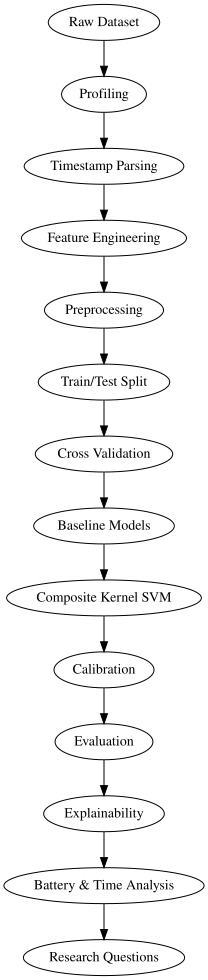

In [164]:
#@title Step 24 (Final Pipeline Diagram)
from graphviz import Digraph

dot = Digraph()

dot.node("A","Raw Dataset")
dot.node("B","Profiling")
dot.node("C","Timestamp Parsing")
dot.node("D","Feature Engineering")
dot.node("E","Preprocessing")
dot.node("F","Train/Test Split")
dot.node("G","Cross Validation")
dot.node("H","Baseline Models")
dot.node("I","Composite Kernel SVM")
dot.node("J","Calibration")
dot.node("K","Evaluation")
dot.node("L","Explainability")
dot.node("M","Battery & Time Analysis")
dot.node("N","Research Questions")

dot.edges([
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("D","E"),
    ("E","F"),
    ("F","G"),
    ("G","H"),
    ("H","I"),
    ("I","J"),
    ("J","K"),
    ("K","L"),
    ("L","M"),
    ("M","N")
])

dot